In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

# plot data

In [2]:
h='0.1'
spin = '0.5'
swt_files = sorted(glob.glob(f'/home/amos1/edgestate/magnon/S{spin}_nnn0.1_dmi0.1_h{h}/*/iterfoo*'))

T_list, Sz_0, Sz_sc = [], [], []
for fi in swt_files:
    T_list.append(float(fi.split('/')[-2][1:]))
    with open(fi, 'r') as f:
        lines = f.readlines()
        vals = lines[0].split()
        Sz_0.append(float(vals[1]))
        vals = lines[-1].split()
        Sz_sc.append(float(vals[1]))

def dmrgplot(files, labels, colors, pscheme="plot"):
    
    for i, fi in enumerate(files):
        data = pd.read_csv(fi)
        m_2 = data.Sz*data.Sz
        m2 = data.M2
        chi = data.beta * (m2 - m_2)*50
        if pscheme=="plot":
            ax.plot(1/data.beta, data.Sz, zorder=1, alpha=0.5,
                marker='.', mfc='none', color=colors[i], mec=colors[i], ms=7, lw=1, ls='--', 
                label=f'DMRG {labels} k{max(data.dim)}')
            ax.plot(1/data.beta, chi, zorder=5, alpha=0.3,
                marker='o', mfc='none', color=colors[i], mec=colors[i], label='Scaled $\\chi_m$', ms=6, lw=1, ls='--')
        elif pscheme=="scatter":
            ax.scatter(1/data.beta, data.Sz, zorder=6, alpha=0.7,
                marker='2', c=colors[i], s=50, 
                label=f'DMRG {labels} k{max(data.dim)}')
            ax.scatter(1/data.beta, chi, zorder=7, alpha=0.7,
                marker='*', fc='none', ec=colors[i], label='Scaled $\\chi_m$', s=30)
            
    
files = sorted(glob.glob(f"../HC_data/126*S0.5*nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi*.csv"))
files = files[1:3]
files

['../HC_data/126_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi-10_db0.01_QNt_k15.csv',
 '../HC_data/126_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi-10_db0.01_QNt_k300.csv']

In [3]:
f_xtrg = sorted(glob.glob(f"../HC_data/126*xtrg*"))
f_xtrg

['../HC_data/126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0008_m13_k400_cut-12_xtrg_ty4.csv',
 '../HC_data/126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0010_m13_k1000_xtrg_ty8.csv',
 '../HC_data/126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0010_m13_k400_cut-12_xtrg_ty4.csv',
 '../HC_data/126_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0010_m13_k400_xtrg.csv']

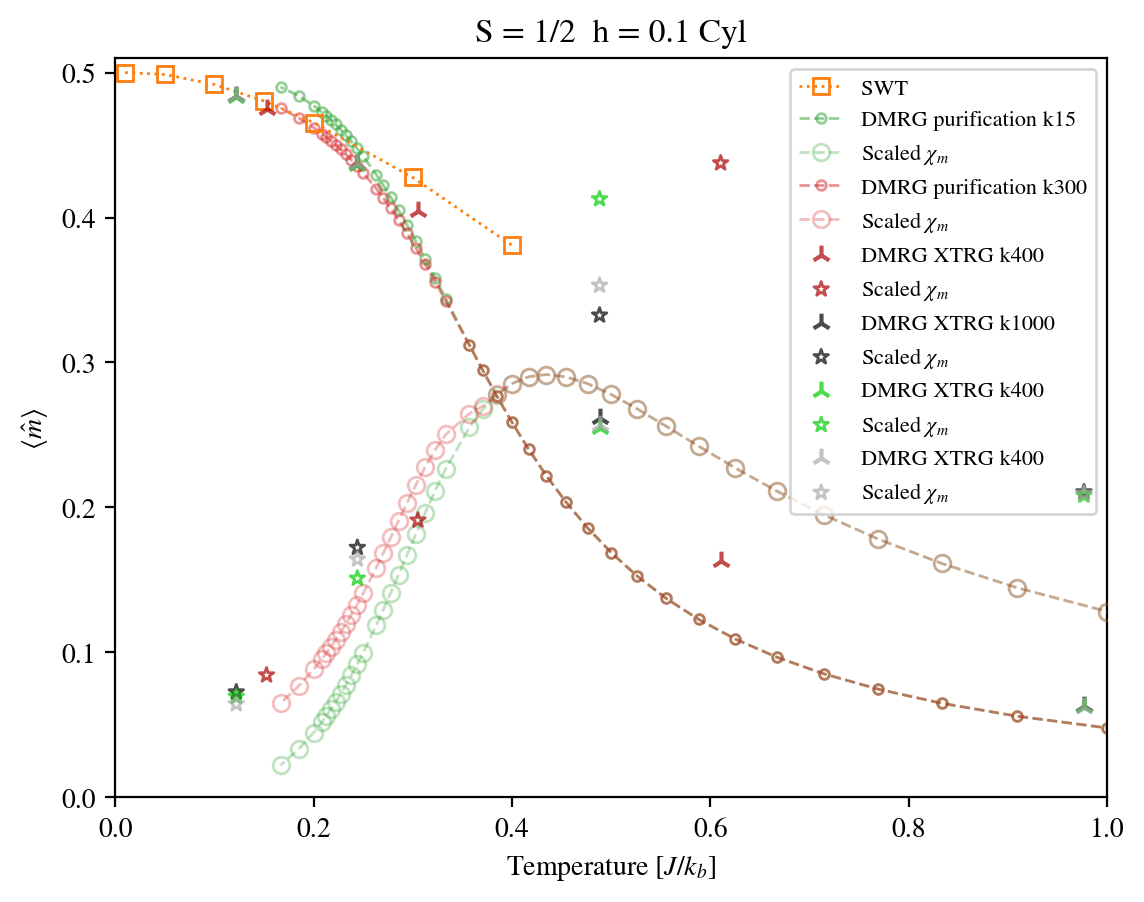

In [6]:
fig, ax = plt.subplots(dpi=200)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'


ax.plot(T_list[:7], Sz_0[:7], 
    marker='s', mfc='none', color='C1', mec='C1', label='SWT', ms=6, lw=1, ls=':')

dmrgplot(files, "purification", ['C2', 'C3'])
dmrgplot(f_xtrg, "XTRG", ['#AA0000', 'k', '#00CC00', '#AAAAAA'],
    pscheme='scatter')

ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0., 0.51)
ax.set_xlabel('Temperature [$J/k_b$]')
ax.set_ylabel('$\\langle \\hat{m} \\rangle$')
ax.set_title('S = 1/2  h = 0.1 Cyl')

plt.show()

# vs purification

In [2]:
# f_xtrg = glob.glob('../HC_data/126_nnn*DM0.0*Oxt*cut0*xtrg_ty8*.csv')
f_xtrg = glob.glob('../HC_data/189_nnn*DM0.1*Oxt*xtrg_ty8.csv')
f_xtrg

['../HC_data/189_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0010_m13_k400_cut0_xtrg_ty8.csv',
 '../HC_data/189_nnn0.10_DM0.10_h0.10_Oxt_Oyf_tau0.0010_m13_k300_cut0_xtrg_ty8.csv']

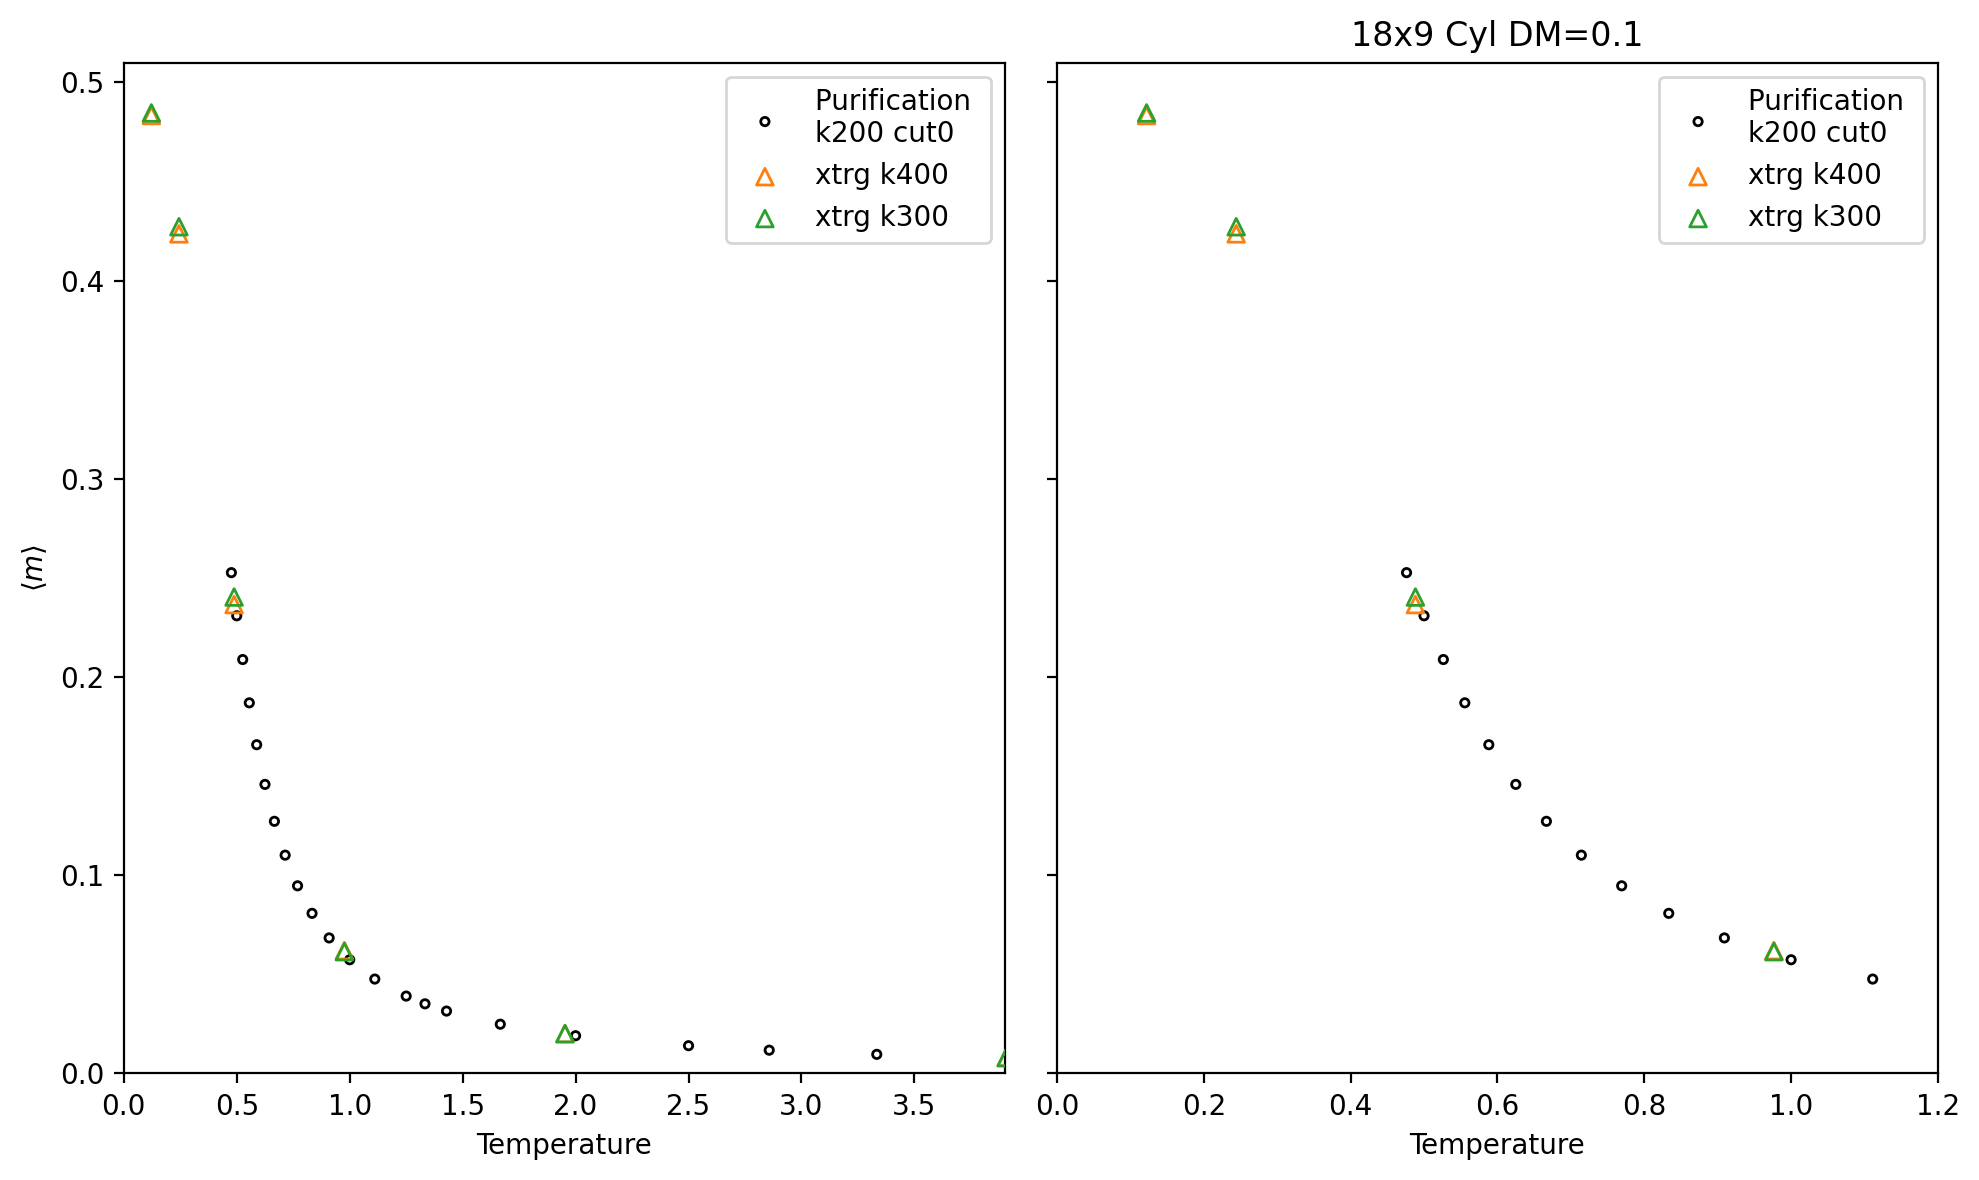

In [6]:
fig, axs=plt.subplots(1, 2, figsize=(10, 6), dpi=200)

n, m = 18, 9
dmrg = pd.read_csv(f'../HC_data/{n}{m}_S0.5_nnn0.10_DM0.10_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv')
# dmrg2 = pd.read_csv(f'../HC_data/{n}{m}_S0.5_nnn0.10_DM0.00_h0.10_Oxt_Oyf_psi0_db0.01_QNt_k200.csv')
# dmrg = pd.read_csv('../HC_data/126_S0.5_nnn0.10_DM0.00_h0.10_Oxt_Oyf_psi-12_db0.01_QNt_k300.csv')
# dmrg2 = pd.read_csv('../HC_data/126_S0.5_nnn0.10_DM0.00_h0.10_Oxt_Oyf_psi-9_db0.01_QNt_k300.csv')

# labels = ['k900 cut-12', 'k900 cut-10', 'k300 cut-10', 'k300 cut-12']
labels = ['k400', 'k300', 'k400', 'k300 2']
# labels = ['ty4', 'ty8', 'ty4', 'ty8']
cs = ['C1', 'C2', 'C3', 'C4']
markers = ['^', '^', '^', 'p']

for ax in axs:
    
    # plot_swt(ax, 11)
    
    # ax.scatter(1/dmrg2.beta, dmrg2.Sz, zorder=6,
    #     marker='s', fc='none', ec='y', label='Purification D=0 \nk200 cut0')
    
    ax.scatter(1/dmrg.beta, dmrg.Sz, zorder=5,
        marker='.', fc='none', ec='k', label='Purification \nk200 cut0')
    for i, f in enumerate(f_xtrg):
        data = pd.read_csv(f)
        ax.scatter(1/data.beta, data.Sz, 
            # fc='none', ec='k', marker='o', zorder=6)
            # fc='none', ec=cs[i], label='xtrg k900 cut-12', marker='o', alpha=0.7, zorder=6)
            fc='none', ec=cs[i], label='xtrg ' + labels[i], marker=markers[i], alpha=1, zorder=10)
    # ax.scatter(11, 0, fc='none', ec='k', marker='o', s=20, label='XTRG')
    
    ax.set_xlabel('Temperature')
    ax.set_ylim(0, 0.51)
    ax.legend()

# plot_chi(axs[1], dmrg2, 'scaled $\\chi$', 25, c='y')
# plot_chi(axs[1], dmrg, 'scaled $\\chi$', 25, c='g')
axs[1].legend()

axs[0].set_xlim(0, 3.9)
axs[1].set_xlim(0, 1.2)
axs[0].set_ylabel("$\\langle m\\rangle$")
axs[1].label_outer()

ax.set_title(f'{n}x{m} Cyl DM=0.1')
plt.tight_layout()
plt.show()

In [8]:
1/1.8

0.5555555555555556

In [4]:
def plot_swt(ax, n):
    
    h='0.1'
    spin = '0.5'
    swt_files = sorted(glob.glob(f'/home/amos1/edgestate/magnon/S{spin}_nnn0.1_dmi0.1_h{h}/*/iterfoo*'))
    swt_O6_files = sorted(glob.glob(f'/home/amos1/edgestate/magnon/S{spin}_nnn0.1_dmi0.1_h{h}*_O6/*/iterfoo*'))

    T_list, Sz_0, Sz_sc = [], [], []
    for fi in swt_files:
        T_list.append(float(fi.split('/')[-2][1:]))
        with open(fi, 'r') as f:
            lines = f.readlines()
            vals = lines[0].split()
            Sz_0.append(float(vals[1]))
            vals = lines[-1].split()
            Sz_sc.append(float(vals[1]))
            
    ax.plot(T_list[:n], Sz_0[:n], 
        marker='d', mfc='none', color='C0', mec='C0', label='SWT', ms=6, lw=1, ls=':')
    ax.plot(T_list[:n], Sz_sc[:n], 
        marker='d', color='C1', mec='C1', label='SCSWT', ms=3, lw=1, ls=':')
    
def plot_chi(ax, data, label, scale, c='k'):
    m_2 = data.Sz*data.Sz
    m2 = data.M2
    chi = data.beta * (m2 - m_2)*scale
    ax.scatter(1/data.beta, chi, zorder=7, alpha=0.7,
        marker='*', fc='none', ec=c, label=label, s=30)

# grid

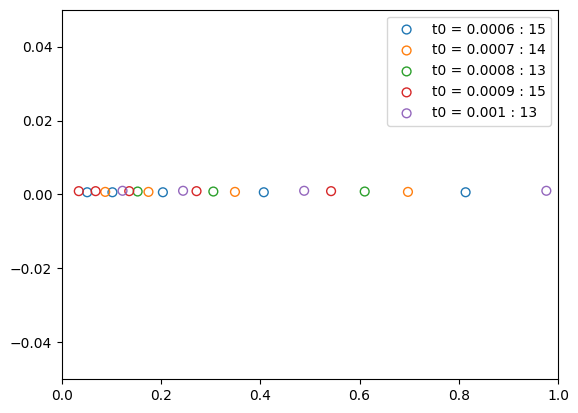

In [2]:
# t0_list = [0.001, 0.0011, 0.0028, 0.003, 0.0034, 0.01]
# m_list = [13, 12, 12, 11, 12, 11]
t0_list = [0.0006, 0.0007, 0.0008, 0.0009, 0.001]
m_list = [15, 14, 13, 15, 13]

betas = lambda t, m: t * 2**np.linspace(1, m, m)

fig, ax = plt.subplots()

for i, t in enumerate(t0_list):
    ax.scatter(
        1/betas(t, m_list[i]), t*np.ones(m_list[i]), s=40,
        marker='o', facecolor='none', edgecolor=f'C{i}', 
        label=f't0 = {t} : {m_list[i]}')

ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 0.05)
plt.show()